# Predicting Battery Health from Early Discharge Behaviour

## Goals

### Motivation

A key objective in battery prognostics is to estimate future battery health using only a short observation of its behaviour. Ideally, we would like to predict the total lifetime of a battery from its earliest charge/discharge cycles—for example, using the first few cycles to estimate that a cell will reach end-of-life after approximately 8,100 drive cycles. However, with only eight batteries available in the Oxford Battery Degradation Dataset, attempting to learn complete lifetime trajectories would almost certainly overfit to the individual cells rather than learn generalisable degradation patterns.

Instead, this notebook investigates a more realistic and well-defined question:

   **How much information about a battery's current and future behaviour is contained within the first few minutes of a single diagnostic discharge cycle?**
   
###  Feature engineering

In the previous notebook we explored the Oxford Battery Degradation Dataset and engineered a set of features describing the early behaviour of each diagnostic discharge cycle.
   
The next step is to investigate how much predictive information is contained within these early measurements.

Rather than allowing the battery to complete its entire discharge before making a prediction, we now deliberately restrict the available information to the first 1, 2, 5, 10 or 20 minutes of each discharge. The observation window can be selected interactively (USE_DEFAULTS = False) or processed automatically to compare multiple window lengths.

The extracted features are then used to train machine learning models for three prediction tasks:

 - **Discharge duration (t_cyc)** – the total duration of the current discharge cycle from its first few minutes.<p>
    
  - **State of Health (SOH)** – the battery's current state of health, expressed as the fraction of its initial discharge capacity (approximated by the ratio of the current discharge duration to the initial discharge duration under constant-current conditions).<p>
 
 - **Remaining Useful Life (RUL)** – the remaining number of drive cycles until the final recorded characterisation cycle using the same early-discharge features.

### Defining Remaining Useful Life (RUL)

The Oxford Battery Degradation Dataset performs detailed diagnostic measurements approximately every 100 drive cycles. The cycle identifiers therefore correspond to the cumulative number of drive cycles completed when each characterisation test was performed, for example:

        Characterisation cycle	Drive cycles completed
                 cyc0000	              0
                 cyc0100	            100
                 cyc0200	            200
                 ...	               ...
                 cyc8200	           8200

For each battery, Remaining Useful Life is defined as the number of cycles remaining from the current one to the final

        RUL = FinalCycle − CurrentCycle

and is therefore expressed in remaining drive cycles.

It is important to note that the Oxford dataset only records detailed characterisation tests periodically (approximately every 100 drive cycles). Consequently, the model predicts the remaining number of drive cycles at *each characterisation point*, rather than continuously throughout the battery's operation. This is a limitation of the available dataset rather than of the modelling approach.

## Process

### Avoiding other sources of data Leakage

Battery degradation datasets require particular care when evaluating machine learning models.

A conventional random train/test split would randomly assign diagnostic cycles from the same battery to both the training and test sets. Because neighbouring cycles are highly correlated, the model can effectively learn each battery's degradation trajectory and interpolate between nearby observations. Although this often produces excellent numerical performance, it does not demonstrate that the model can generalise to a battery it has never encountered.

This phenomenon is better described as *trajectory leakage* or *dependency leakage*. No future measurements are leaked directly into the training data, but the training and test observations are no longer statistically independent.

To evaluate genuine generalisation performance, this notebook uses *Leave-One-Group-Out* (LOGO) cross-validation, treating each battery as a separate group. During each fold the model is trained using seven complete batteries and evaluated on the remaining unseen battery. This directly answers the practical question:

   *If presented with a completely new battery, can the model estimate its health using only the first few minutes of a diagnostic discharge?*

### Machine learning

In the following code we:

- **Import data**

    Import the CSV of the single test extracted from the MATLAB file created in Notebook 1.<p>
    
- **Engineer features**  

   As per Notebook 2, but limit these to a given observation window. For a single trial 1, 2, 5, 10 or 20 minutes can be selected from a dropdown menu.<p>
       
- **Choose the target feature**
   
   Either the discharge duration, SOH or RUL via a dropdown menu.<p>
        
- **Apply machine learning**
       
  Five regression algorithms are compared, ranging from a Dummy Regressor (baseline) through Linear Regression and Ridge Regression to the tree-based Random Forest and Histogram Gradient Boosting regressors. The linear models provide a simple benchmark for approximately linear relationships, while the ensemble methods can capture complex, non-linear interactions between the engineered voltage and temperature features. Comparing these models helps determine whether battery behaviour can be adequately described by simple relationships or whether more flexible machine learning methods provide a measurable advantage.<p>
      
- **Report the metrics**
      
  We use several metrics to quantify how well the predictions follow the measurements:<p>
      
    - The root mean squared error (RMSE) over $N$ data points between the predictions and the measurements, $\sigma_{\rm RMS} \equiv  \sqrt{\frac{1}{N}\sum_{i=1}^N \Delta y^2}$, where $\Delta y = y_{\rm pred} - y_{\rm meas}$.<p>
  
    - The mean absolute error (MAE),the average magnitude of errors between predicted and actual values, $\sigma_{\rm MAE} \equiv  \sqrt{\frac{1}{N}\sum_{i=1}^N |\Delta y|}$.<p>
      
   - The median absolute error (MedAE), which takes the median of the absolute errors and is therefore not as sensitive to outliers as the MAE. <p>
      
   - The Pearson correlation coefficient, calculated between predictions the measurements. This can range over $-1 \leq r_{\rm Pearson} \leq +1$ with:
      - $r_{\rm Pearson}  \approx +1$: The predicted and measured points move together in a straight line. 
      - $r_{\rm Pearson}  \approx 0$: There is little linear relationship.
      - $r_{\rm Pearson}  \approx -1$: The model is tracing the trend backwards. Low values should be high and vice versa.<p>
      
    - The regression coefficient ($R^2$).<p>
      
    - A linear fit to $y_{\rm pred}$ versus $y_{\rm meas}$, giving
        - The gradient, where $m=1$ shows that the predicted values scale perfectly with the measured values.
        - The intercept, where $c=0$ signififies no offset bias.<p>
      
### Meta-analysis
            
By default, the number of trials is set to one and the complete feature dataset is used to generate the reported predictions and visualisations.
            
By setting 

        USE_DEFAULTS = False

a meta-analysis can be performed by setting  num_trials > 1. Here each trial randomly samples 85% of the available characterisation cycles before training. This does not replace the Leave-One-Group-Out validation; the test battery always remains completely isolated.

In [1]:
from pathlib import Path
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
project_root_abs = os.path.abspath(PROJECT_ROOT)
sys.path.insert(0, project_root_abs)

from src.loader import load_oxford_dataset
from src.plotter import spines

USE_DEFAULTS = False # True = runs presets silently | False = uses custom options below

In [2]:
df = load_oxford_dataset("C1dc")
display(df)

Reading cached Parquet dataset:
/Users/stephencurran/steviecurran.github.io/battery-degradation-prediction/github/data/Oxford_Battery_Dataset_Test=C1dc.parquet


,Cell,Cycle,Test,Time_min,Voltage_V,Charge_mAh,Temperature_C
0,1,0,C1dc,0.000000,4.191235,0.000000,40.026463
1,1,0,C1dc,0.016667,4.175756,-0.194831,40.051395
2,1,0,C1dc,0.033333,4.174312,-0.399788,39.988987
3,1,0,C1dc,0.050000,4.172628,-0.604746,39.976521
4,1,0,C1dc,0.066667,4.171545,-0.809702,39.964054
...,...,...,...,...,...,...,...
1610373,8,8100,C1dc,45.283278,2.750167,-558.299455,41.591419
1610374,8,8100,C1dc,45.299945,2.735212,-558.504936,41.603924
1610375,8,8100,C1dc,45.316611,2.719576,-558.710416,41.529045
1610376,8,8100,C1dc,45.333278,2.703419,-558.915894,41.653828


In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.stats import linregress
from scipy.integrate import trapezoid  
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,median_absolute_error
from src.plotter import ML_plot, meta_plot

warnings.simplefilter(action='ignore', category=np.RankWarning)

# ==============================================================================
# METRIC EXTRACTION 
# ==============================================================================
def extract_window_features(df_raw, window_minutes):
    if df_raw is None or df_raw.empty:
        return pd.DataFrame()
      
    rows = []
    for (cell, cycle), g in df_raw.groupby(["Cell", "Cycle"]):
        g = g.sort_values("Time_min")
        capacity = abs(g["Charge_mAh"].max())
        early = g[g["Time_min"] <= window_minutes]
        
        # Guard clause ensures there are enough physical data points to run calculations
        if len(early) < 20:
            continue

        vfit = linregress(early["Time_min"], early["Voltage_V"])
        tfit = linregress(early["Time_min"], early["Temperature_C"])
        coeff = np.polyfit(early["Time_min"], early["Voltage_V"], 2)
        auc = trapezoid(early["Voltage_V"], early["Time_min"])
        
        rows.append({
            "Cell": cell, "Cycle": cycle,
            "V_start": early["Voltage_V"].iloc[0],      
            "V_end": early["Voltage_V"].iloc[-1],
            "V_mean": early["Voltage_V"].mean(), 
            "V_std": early["Voltage_V"].std(),
            "V_slope": vfit.slope, 
            "V_curve": coeff[0],                         
            "VTI": auc,
            "T_start": early["Temperature_C"].iloc[0],  
            "T_end": early["Temperature_C"].iloc[-1], 
            "T_mean": early["Temperature_C"].mean(), 
            "T_std": early["Temperature_C"].std(),
            "T_slope": tfit.slope,
            "q_end": abs(early["Charge_mAh"].iloc[-1]),
            "Capacity_mAh": capacity,
            "t_end": early["Time_min"].iloc[-1],       
            "t_cyc": g["Time_min"].max()                
        })

    df_extracted = pd.DataFrame(rows)
    if not df_extracted.empty:
        df_extracted["FinalCycle"] = df_extracted.groupby("Cell")["Cycle"].transform("max")
        df_extracted["InitialCapacity"] = df_extracted.groupby("Cell")["Capacity_mAh"].transform("first")
        # ─── STRUCTURAL STATE OF HEALTH (SOH) CALCULATION ───────────────
        # We isolate the very first row entry (Cycle 0/Minimum Cycle) per Cell ID, 
        # extract its 't_cyc' value as the pristine baseline, and divide the current 
        # cycle's 't_cyc' by that value to find the true fractional health target.
        initial_times = df_extracted.groupby("Cell")["t_cyc"].transform("first")
        df_extracted["SOH"] = df_extracted["t_cyc"]/initial_times
        # ─────────────────────────────────────────────────────────────────────
        
        df_extracted["RUL"] = df_extracted["FinalCycle"] - df_extracted["Cycle"]
    return df_extracted

# ==============================================================================
# INTEGRATED WORKFLOW SWEEP MANAGER
# ==============================================================================
def pipeline_manager(window_view, target, chosen_model_name, num_trials):
    if 'df' not in globals() or df is None or df.empty:
        print("⚠️ Raw master data container 'df' is uninitialized. Load the raw dataset first.")
        return

    if num_trials > 1:
        #windows_to_process = [1] # FOR TESTING
    
        windows_to_process = [i for i in range(1,11)]
        windows_to_process.append(15)
        windows_to_process.append(20)
        windows_to_process.append(30)
        #print(windows_to_process)
     
        print(f"🚀 MULTI-TRIAL META-ANALYSIS DETECTED\n Sweeping through {windows_to_process} min windows...")
    else:
        windows_to_process = [float(window_view)]
        print(f"⚙️ SINGLE RUN MODE ACTIVE: Target Window = {window_view} minutes")

    master_sweep_records = []
    single_run_predictions = []

    regressors = {
        "Dummy": DummyRegressor(),
        "Linear": LinearRegression(),
        "Ridge": Ridge(),
        "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
        "Gradient Boosting": HistGradientBoostingRegressor(random_state=42)
    }

    for current_window in windows_to_process:
        print(f"⚡ Processing Window Length: {current_window} minutes...")
        dfc_local = extract_window_features(df, window_minutes=current_window)
        
        if dfc_local.empty:
            print(f"⚠️ Feature matrix empty for window {current_window}. Skipping.")
            continue
          
        for trial in range(1, num_trials + 1):
            
            if num_trials > 1 and trial > 1:
                df_working = dfc_local.sample(frac = 0.85,random_state=42 + trial).copy()

            else:
                df_working = dfc_local.copy()
            
            # Safely isolate data tables loop-free
            df_working = df_working.drop(columns=["t_end"], errors='ignore')
            groups = df_working["Cell"]
            cycles = df_working["Cycle"]
            X = df_working.drop(columns=['t_cyc', "Cell", "Cycle", "FinalCycle","RUL","SOH"], 
                                errors='ignore')
        
            y = df_working[target]
            
            logo = LeaveOneGroupOut()

            for train_idx, test_idx in logo.split(X, y, groups):
                test_cell = groups.iloc[test_idx].iloc[0]
                test_cycles = cycles.iloc[test_idx]

                X_train = X.iloc[train_idx].copy()
                X_test = X.iloc[test_idx].copy()
                y_train = y.iloc[train_idx]
                y_test = y.iloc[test_idx]

                scaler = StandardScaler()
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

                model = regressors[chosen_model_name]
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                
                rms = np.sqrt(mean_squared_error(y_test, y_pred))
                mae = mean_absolute_error(y_test, y_pred)
                medae = median_absolute_error(y_test, y_pred)
                
                r2 = r2_score(y_test, y_pred)
                r_val = np.corrcoef(y_test, y_pred)[0, 1] if np.std(y_pred) > 0 and np.std(y_test) > 0 else 0.0
                p = np.polyfit(y_test, y_pred, 1)
                # We divide by the mean of the actual test cell values to find the fraction, 
                baseline_val = np.mean(y_test)
                rms_frac = (rms / baseline_val)
                mae_frac = (mae / baseline_val) 
                medae_frac = (medae / baseline_val) 
                
                master_sweep_records.append({
                    "Window_Minutes": current_window, "Trial_ID": trial, 
                    "Model": chosen_model_name, "Target": target, "Cell": test_cell, 
                    "RMSE": rms, "MAE": mae, "MedAE": medae, 
                    "RMSE_frac": rms_frac, "MAE_frac": mae_frac,"MedAE_frac": medae_frac,
                    "r": r_val, "R2": r2, "m": p[0], "c": p[1]})

                if num_trials == 1:
                    single_run_predictions.append(pd.DataFrame({
                        "Cell": test_cell, "Cycle": test_cycles.values, "Model": chosen_model_name,
                        "Actual": y_test.values, "Predicted": y_pred, "t_end": current_window
                    }))

    history_df = pd.DataFrame(master_sweep_records)

    if num_trials == 1:
        print("\n📊 Cross Validation Performance Summary Matrix:")
        print("-" * 90)
        summary = history_df.groupby("Model").agg(
            RMSE_mean=("RMSE", "mean"),MAE_mean=("MAE", "mean"), 
            MedAE_mean=("MedAE", "mean"), 
            r_mean=("r", "mean"), R2_mean=("R2", "mean"),
            m_mean=("m", "mean"), c_mean=("c", "mean")
        )
        display(summary)
        prediction_results = pd.concat(single_run_predictions, ignore_index=True)
        ML_plot(prediction_results, target, chosen_model_name)
    
    else:
        meta_summary = history_df.groupby(["Window_Minutes", "Model", "Target"]).agg(
            RMSE_mean=("RMSE_frac", "mean"), RMSE_std=("RMSE_frac", "std"),
            MAE_mean=("MAE_frac", "mean"), MAE_std=("MAE_frac", "std"),
            RMSE_frac_mean=("RMSE_frac", "mean"), MAE_frac_mean=("MAE_frac", "mean"),
            R2_mean=("R2", "mean"), R2_std=("R2", "std")
        ).reset_index()
        
        print("\n📊 Consolidated Window-Sweep Performance Averages Table:")
        print("-" * 90)
        display(meta_summary.round(3))
        meta_plot(history_df) 
                
        out_dir = "../data"
        os.makedirs(out_dir, exist_ok=True)
        out_file = f"{out_dir}/meta_global_window_sweep_model={chosen_model_name}_trials={num_trials}_target={target}.csv"
        
        history_df.to_csv(out_file, index=False)
        print(f"\n✅ Success! Multi-window master log written directly to disk:\n 👉 {out_file}")

if USE_DEFAULTS:
    target = "RUL"; chosen_model_name = "Random Forest"; num_trials = 1
    window_view = 5
    pipeline_manager(window_view, target, chosen_model_name, num_trials)
else:
    dd_win_view = widgets.Dropdown(options=['1','2','5','10','20'], 
                                   value='5',
                                   description='Window (min):', 
                                   style={'description_width': 'initial'},
                                   layout={'width': '20%'})
    
    dd_targ = widgets.Dropdown(options=['t_cyc','SOH','RUL'], value='t_cyc',
                               description='Target feature:', 
                               style={'description_width': 'initial'},
                               layout={'width': '25%'})
    
    dd_model = widgets.Dropdown(options=['Dummy', 'Linear', 'Ridge', 
                                         'Random Forest', 'Gradient Boosting'], 
                                value='Random Forest', description='Model:', 
                                style={'description_width': 'initial'},
                                layout={'width': '25%'})

    
    dd_trials = widgets.Dropdown(options=[1,10, 100], value=1,
                                 description='No. of trials:', 
                                 style={'description_width': 'initial'},
                                 layout={'width': '20%'})
    
    menu = widgets.HBox([dd_win_view, dd_targ, dd_model, dd_trials])
    ui = widgets.VBox([menu])
    clear_output(wait=True)
    out = widgets.interactive_output(pipeline_manager,
                                     {'window_view': dd_win_view,'target': 
                                      dd_targ,'chosen_model_name': dd_model,
                                      'num_trials': dd_trials})
    display(ui, out)

Output()

The above above plot shows the values predicted for that cell based on training on the other seven (the values on the table are averaged across all tests).
From the default setting (a single trial over a 5 minute window):

- **Discharge duration (t_cyc)** 
  
  All non-dummy models give exceptionally good predictions, with the Random Forest and Gradient Boosting regressors giving the lowest RMSE averaged over all cells ($\sigma_{\rm RMS}\approx30$ seconds over a 1 hour discharge cycle). <p>
    
- **State of Health (SOH)**
    
   Again, all exceptionally good predictions, with the Random Forest and Gradient Boosting regressors giving $\sigma_{\rm RMS}\lesssim0.01$. <p>
    
 
- **Remaining Useful Life (RUL)**
      
   Remaining Useful Life proved to be the most challenging prediction task. The best-performing models, Random Forest and Gradient Boosting, achieved a mean $\sigma_{\rm RMS}\sim10^3$ drive cycles.

    Inspection of the individual cell predictions provides considerably more insight than the aggregate metrics alone.

    Although the coefficient of determination ($R^2$) is relatively poor for several cells, the Pearson correlation coefficients are consistently $r_{\rm Pearson}\approx1$, indicating that the models successfully capture the underlying degradation trends.

    The additional linear calibration analysis helps explain this apparent contradiction. For the more difficult cells (particularly Cells 4, 7 and 8), the fitted gradients deviate noticeably from  unity ($m\not\approx 1$), indicating that the rate of degradation is systematically over- or under-estimated. Furthermore, Cells 4 and 8 exhibit substantial non-zero intercepts ($|c| \gg 0$), revealing an additional offset bias between the predicted and measured Remaining Useful Life.

    Nevertheless, even for these more challenging batteries, the models reproduce the overall degradation trajectory. Given that the models are trained using data from only seven other batteries and evaluated on a completely unseen eighth battery, these results demonstrate encouraging generalisation despite the extremely limited size of the dataset.

### Multi-Trial Robustness Analysis

The above results are encouraging, but based upon a single trial (defaulted to an observation window of the first 5 minutes). The observation window can be varied, but in order to test robustly the shortest window which gives a reliable result, we run a meta-analysis, where a variety of observation windows are be run several times.

The purpose of this random subsampling is to evaluate the robustness of the modelling pipeline rather than to improve predictive accuracy. It serves three purposes:

- **Robustness to missing measurements**

  Real battery telemetry is rarely complete. Randomly omitting observations simulates missing diagnostic measurements or incomplete sensor logs and tests whether the engineered features remain informative.<p>
    
- **Model stability**

  Repeating the experiment on slightly different datasets allows the variability of metrics to be quantified, providing confidence intervals rather than single point estimates<p>

- **Validation integrity**
    
  Because Leave-One-Group-Out is still used, no information from the held-out battery is ever incorporated into the training data. The evaluation therefore remains free from trajectory leakage.
      
This can take a while to run, so a demo plot is shown below.      

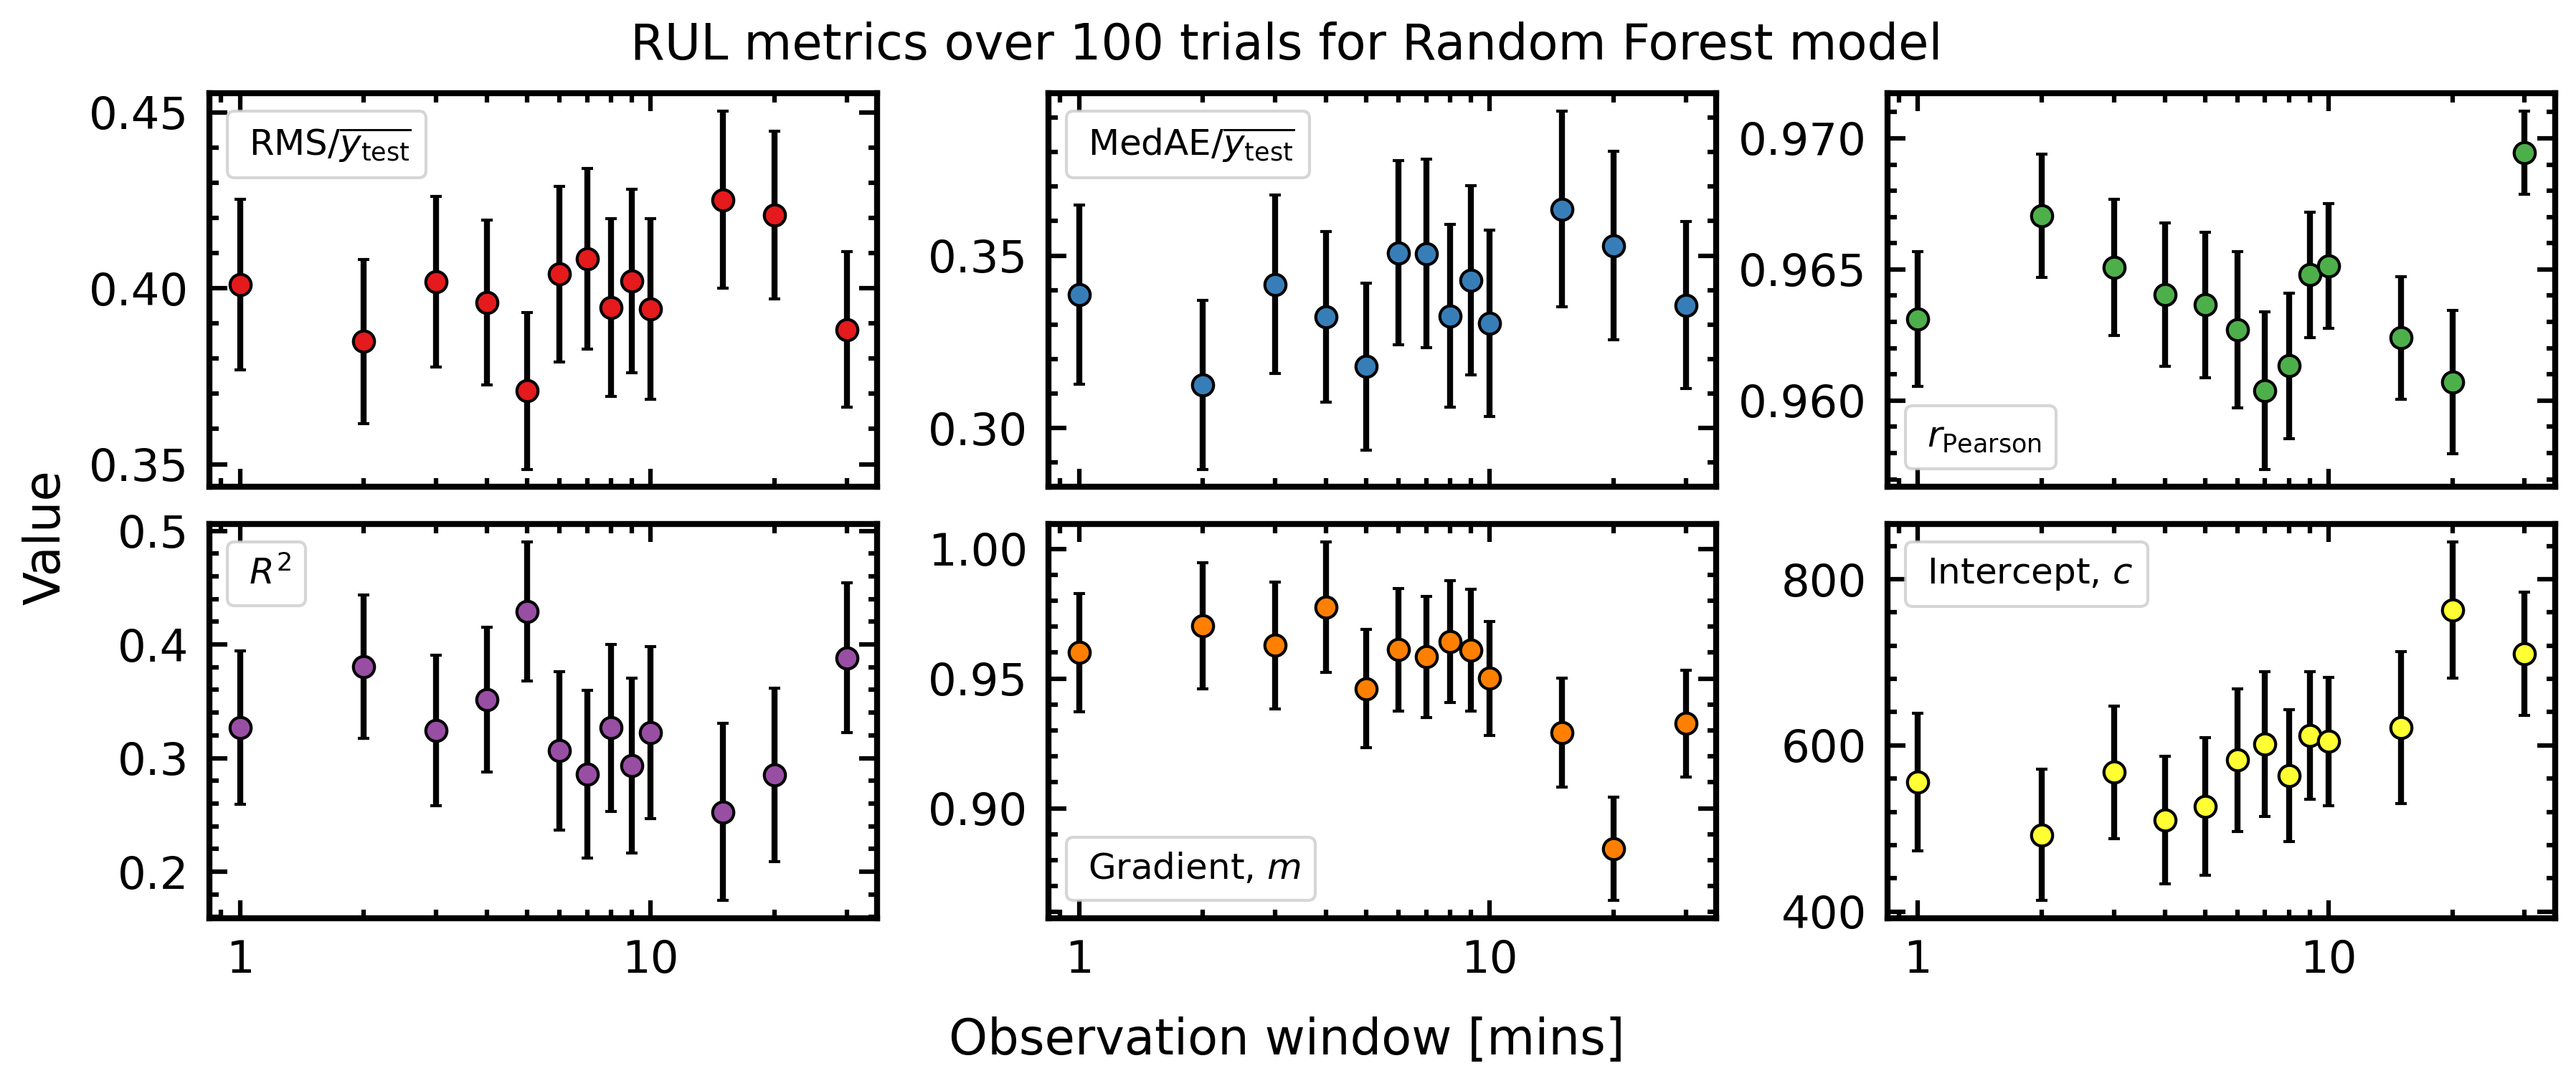

In [4]:
from IPython.display import Image, display
image_path = "../assets/images/meta_metrics_target=RUL_model=RF_trials=100.png"
display(Image(filename=image_path, width=800))

In the output plot, the points show the mean value of each metric over the trials and the error bars the $1\sigma$ standard errors ($\sigma/\sqrt{N}$).

For the example shown above, the RUL prediction over 100 trials:

  - The lowest value of the fractional RMS ($\sigma_{\rm RMS}$ normalised by the mean test value, $\overline{y_{\rm test}}$) is for a window of 5 minutes, although these only confidently increase at $t\gtrsim10$ minutes.<p>
    
  - The fractional MedAE is approximately equal the RMSE, suggesting  exceptionally good, predictable and stable model behavior, free of heavy-tailed outliers.<p>
  
  -  The Pearson coefficient is high with $r_{\rm Pearson}\gtrsim0.96$.<p>
      
  - The regression coefficient hovers at $R^2 \approx0.3$, depite the high values of $r_{\rm Pearson}$, which suggests a scale or calibration error. <p>
      
  - Both the gradient and intercept are within $\approx5$% of the target value (for 8000 cycles) and it is therefore possible that both scaling and calibration contribute to the 
poor $R^2$.

## Results

The following results are obtained using Leave-One-Group-Out cross-validation and represent the average performance across the eight cells unless otherwise stated.

The Random Forest and Gradient Boosting regressors consistently outperformed the linear models for all three prediction tasks. Leave-One-Group-Out validation demonstrated that the models were able to generalise to previously unseen batteries despite the limited size of the dataset.<p>

**Discharge duration (t_cyc)**

Discharge duration was predicted with high accuracy by all non-dummy models. Random Forest and Gradient Boosting produced the lowest errors, with an average RMSE of approximately 30 seconds over discharge cycles lasting around one hour. The predicted values closely followed the measured discharge durations for every battery, indicating that the early voltage and temperature response contains sufficient information to characterise the remainder of the discharge.<p>

**State of Health (SOH)**

SOH proved similarly predictable, with Random Forest and Gradient Boosting achieving errors below approximately 1% of the initial battery health. Since SOH was derived from the relative discharge duration under constant-current conditions, these results indicate that the engineered features successfully capture the battery's current electrochemical condition.<p>

**Remaining Useful Life (RUL)**

Remaining Useful Life was substantially more challenging. Although the models reproduced the overall degradation trends for most batteries, larger systematic offsets were observed, particularly for Cells 4, 7 and 8. High Pearson correlation coefficients demonstrated that the models captured the underlying progression of degradation, while the comparatively modest $R^2$
 values reflected calibration differences between individual batteries rather than completely incorrect predictions.<p>

**Observation window**

Increasing the observation window beyond approximately five minutes produced little improvement in predictive performance. Across repeated trials, the shortest windows frequently achieved performance comparable to, and occasionally better than, substantially longer observation periods. This suggests that the majority of diagnostically useful information is contained within the initial transient response of the discharge.

### Conclusions

This notebook investigated whether the behaviour of a lithium-ion battery during the first few minutes of a diagnostic discharge contains sufficient information to predict both its current condition and aspects of its future behaviour. To ensure realistic performance estimates, all models were evaluated using Leave-One-Group-Out cross-validation, in which each battery was treated as an entirely unseen test case. This avoids trajectory leakage that would otherwise occur with conventional random train/test splitting and provides a more representative estimate of how the models would perform on newly manufactured batteries.



An unexpected outcome of the meta-analysis was that increasing the observation window beyond approximately five minutes did not consistently improve predictive performance. In several cases, the shortest observation windows performed as well as, or even slightly better than, substantially longer windows. This suggests that much of the diagnostically useful information is contained within the initial transient response of the battery, while later measurements provide comparatively little additional information for these prediction tasks.

Overall, these results demonstrate that relatively simple machine learning models, combined with carefully engineered features and rigorous validation, can extract significant information about battery health from only a brief portion of a diagnostic discharge. More importantly, the notebook illustrates the importance of selecting an evaluation methodology that reflects the intended deployment scenario. High predictive accuracy obtained from conventional random train/test splits can be misleading when observations from the same battery appear in both training and testing data. By evaluating performance on entirely unseen batteries, the reported results provide a more realistic assessment of the ability of these models to generalise.

This work highlights the trade-off between predicting a battery's current condition and predicting its future lifetime. Present health indicators such as discharge duration and SOH can be estimated with high accuracy from a short observation window, whereas forecasting Remaining Useful Life remains substantially more difficult because it depends on degradation processes that have yet to occur. This distinction is fundamental to battery prognostics and explains why RUL prediction continues to be an active area of research.


Although this study used only eight batteries, it demonstrates an important principle: carefully engineered features extracted from only the first few minutes of a diagnostic discharge contain sufficient information to estimate a battery's current condition with high accuracy, while future lifetime remains a considerably more challenging prediction problem. Equally important, the work highlights that rigorous evaluation methodology is essential—models must be assessed on entirely unseen batteries if they are to provide realistic estimates of real-world performance.

## Future Work

This study provides a proof of concept using a small research dataset. Several natural extensions would improve both the scientific understanding and practical applicability of the approach:

- Validate the methodology on larger battery degradation datasets containing hundreds or thousands of cells.

- Investigate richer time-series models (e.g. LSTMs or Transformers) that operate directly on voltage and temperature traces rather than engineered summary features.

- Incorporate additional sensing modalities such as impedance measurements, internal resistance or charging behaviour.

- Investigate transfer learning between different battery chemistries and operating conditions.

- Explore uncertainty estimation so that predictions are accompanied by confidence intervals rather than point estimates.

- Evaluate performance on continuously collected operational data rather than periodic characterisation cycles.